In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import simple_norm

%matplotlib widget

3.13.3 | packaged by conda-forge | (main, Apr 14 2025, 20:44:03) [GCC 13.3.0]
/home/firestar/.miniconda/bin/python


In [22]:
# Combine CRAFTS data cubes

file1 = "CRAFTS_RA60_80_DEC-13_2_-_moment0.fits"
file2 = "CRAFTS_RA80_100_DEC-13_2_-_moment0.fits"
file3 = "CRAFTS_RA100_120_DEC-13_2_-_moment0.fits"
file4 = "CRAFTS_RA120_140_DEC-13_2_-_moment0.fits"
output_file = './combined/CRAFTS_RA60_140_DEC-13_2_-_moment0.fits'

hdul1 = fits.open(file1)
hdr1 = hdul1[0].header
data1 = hdul1[0].data

hdul2 = fits.open(file2)
hdr2 = hdul2[0].header
data2 = hdul2[0].data

hdul3 = fits.open(file3)
hdr3 = hdul3[0].header
data3 = hdul3[0].data

hdul4 = fits.open(file4)
hdr4 = hdul4[0].header
data4 = hdul4[0].data

In [23]:
print(data1.shape, data2.shape, data3.shape, data4.shape)
combined_data = np.concatenate((data4, data3, data2, data1), axis=1)
print("Shape of combined data:", combined_data.shape)
combined_header = hdr4.copy()

(600, 800) (600, 800) (600, 800) (600, 800)
Shape of combined data: (600, 3200)


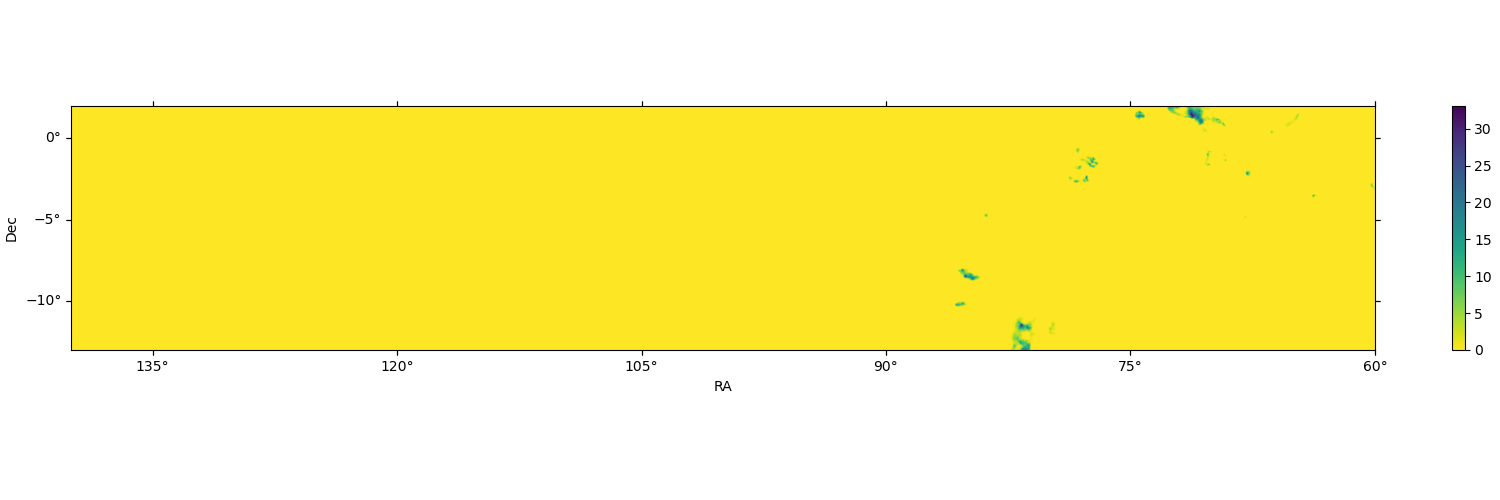

In [24]:
def displayimage(img, wcs):
    fig, ax = plt.subplots(
        figsize=(15, 5), layout="compressed", subplot_kw={"projection": wcs}
    )
    norm = simple_norm(np.array(img), vmin=np.nanmin(img), vmax=np.nanmax(img), stretch="linear")
    im = ax.imshow(img, norm=norm, cmap="viridis_r", origin="lower")
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter("dd")
    lat.set_major_formatter("dd")
    lon.set_axislabel("RA")
    lat.set_axislabel("Dec")
    plt.colorbar(im)
    plt.show()

displayimage(combined_data, WCS(combined_header))

In [25]:
hdu = fits.PrimaryHDU(data=combined_data, header=combined_header)
hdul = fits.HDUList([hdu])
hdul.writeto(output_file, overwrite=True)